## Testing docker images

* troubleshot docker images
* bmi-model implementation
* bmi-plugin implementation

current date: 2026-02-13



In [1]:
# docker build -t ewatercycle-pcr-13feb .
# docker save -o ewatercycle_pcr_13feb.tar ewatercycle-pcr-13feb
# apptainer build ewatercycle_pcr_13feb.sif docker-archive://ewatercycle_pcr_13feb.tar

In [58]:
import sys
from pathlib import Path

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage
from rich import print

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

from src.aral import load_grdc_monthly
from src.constants import STATIONS_PCR
from src.paths import FORCING_PCRGLOB, GRDC, INI_FILES, LOAD_PCR, PCR_GLOBAL_PARAMS, PCR_TAIL

In [3]:
STATIONS_PCR

{'Chatly': {'lat': 42.2, 'lon': 60.2},
 'Kazalinsk': {'lat': 45.7, 'lon': 62.12},
 'Kerki': {'lat': 37.83, 'lon': 65.25},
 'Tyumen-Aryk': {'lat': 43.95, 'lon': 67.05},
 'Karaozek': {'lat': 44.95, 'lon': 65.27}}

In [4]:
pcr_glob_directory = PCR_GLOBAL_PARAMS  # GlobalOption uit .ini
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL


parameter_set_test = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "test_container_images.ini",
    target_model="pcrglobwb",
    supported_model_versions={"13feb"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

In [5]:
my_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_13feb.sif")
my_image.version

'13feb'

In [6]:
reference = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)


print(reference)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_i
n_progress/model_runs/pcrglobwb/ini_files/test_container_images.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'13feb'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='1940-01-01T00:00:00Z',
        end_time='1960-12-31T00:00:00Z',
        directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/wor
k_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script'),
        shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1960_AralSea_basin.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-1960_AralSea_basin.nc'
    )
)

In [7]:
experiment_start_date = "1950-01-01T00:00:00Z"
experiment_end_date = "1950-01-31T00:00:00Z"

In [8]:
reference_config, reference_dir = reference.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)
reference_config, reference_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260216_111945/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260216_111945')

In [9]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-01-31T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 30

In [10]:
print("Using config:", reference_config)

Using config: 
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/explo
ration/Image_tests/pcrglobwb_20260216_111945/pcrglobwb_ewatercycle.ini

In [11]:
reference.initialize(reference_config)

In [12]:
time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
)
stations_timeseries.head()


stations_timeseries_reference = stations_timeseries.copy()

In [13]:
for _ in tqdm(range(number_of_days), desc="Running model"):
    reference.update()

print("Model run finished!")

Running model:   0%|          | 0/30 [00:00<?, ?it/s]

Model run finished!

In [14]:
reference.finalize()

## test get value

bmi implementation

In [15]:
get_value_experiment_start_date = "1949-01-01T00:00:00Z"
get_value_experiment_end_date = "1950-12-31T00:00:00Z"

In [16]:
test_get_value = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

In [17]:
test_get_value_config, test_get_value_dir = test_get_value.setup(
    start_time=get_value_experiment_start_date,
    end_time=get_value_experiment_end_date,
    max_spinups_in_years=1,
)
test_get_value_config, test_get_value_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260216_112312/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260216_112312')

In [18]:
print(reference.parameters)

test_get_value_para = test_get_value.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(get_value_experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(get_value_experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-01-31T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 729

In [19]:
test_get_value.initialize(test_get_value_config)

In [20]:
for _ in tqdm(range(number_of_days), desc="Running model"):
    test_get_value.update()

    # Track discharge at station locations
    time = test_get_value.time_as_isostr

    for station_name, coords in STATIONS_PCR.items():
        discharge = test_get_value.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        stations_timeseries.loc[time, station_name] = discharge[0]

    # test_values = test_get_value.get_value("discharge")
    # print(f"max = {np.max(test_values)}")

#     discharge_at_station = test_get_value.get_value_at_coords(
#     "discharge",
#     lat=[lat],
#     lon=[lon]
# )


# print(type(test_values))
print("Model run finished!")

# print(type(discharge_at_Chatly))

Running model:   0%|          | 0/729 [00:00<?, ?it/s]

Model run finished!

In [21]:
test_get_value.finalize()

In [52]:
grdc_station_id = "2817100"
data_home = GRDC / "Daily"

observations = ewatercycle.observation.grdc.get_grdc_data(
    station_id=grdc_station_id,
    start_time="1900-01-01T00:00:00Z",  # or: model_instance.start_time_as_isostr
    end_time="1990-12-15T00:00:00Z",
    data_home=data_home,
)
observations

<xarray.Dataset> Size: 223kB
Dimensions:              (time: 13880)
Coordinates:
  * time                 (time) datetime64[ns] 111kB 1936-01-01 ... 1973-12-31
    id                   int64 8B 2817100
Data variables:
    streamflow           (time) float64 111kB 688.0 664.0 614.0 ... 153.0 158.0
    area                 float64 8B 4.5e+05
    country              <U2 8B 'UZ'
    geo_x                float64 8B 59.7
    geo_y                float64 8B 42.28
    geo_z                float64 8B 72.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U6 24B 'CHATLY'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2817100_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

In [53]:
Syr_kaza = load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = load_grdc_monthly(2817100, name="Amu Darya Chatly")

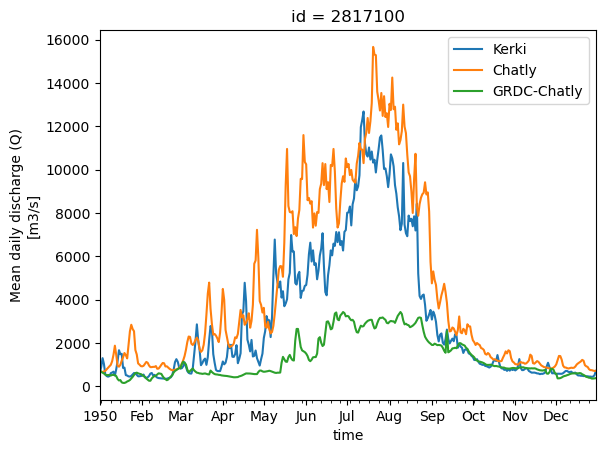

In [60]:
stations_timeseries.loc["1950"][["Kerki", "Chatly"]].plot()
observations.sel(time="1950")["streamflow"].plot(label="GRDC-Chatly")
plt.legend()
# stations_timeseries.plot()

<Axes: xlabel='time'>

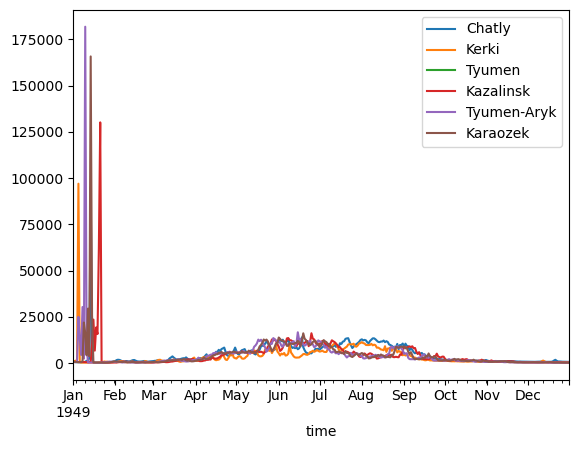

In [23]:
stations_timeseries.loc["1949"].plot()